In [1]:
import torch
from torchvision import models
import matplotlib.pyplot as plt
import numpy as np

resnet = models.resnet18(weights='IMAGENET1K_V1')
print(resnet)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\000010478/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:35<00:00, 1.32MB/s]

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [2]:
from torchvision import transforms
from PIL import Image
from io import BytesIO
import requests

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

imgs = [
    "https://learnopencv.com/wp-content/uploads/2019/05/dog.jpg",
    "https://learnopencv.com/wp-content/uploads/2021/01/strawberries.jpg",
    "https://learnopencv.com/wp-content/uploads/2021/01/automotive.jpg",
    "https://learnopencv.com/wp-content/uploads/2021/06/Getting_Started_with_Opencv.jpg",
    "https://learnopencv.com/wp-content/uploads/2021/06/sample.jpg",
    "https://t3.ftcdn.net/jpg/01/97/11/64/360_F_197116416_hpfTtXSoJMvMqU99n6hGP4xX0ejYa4M7.jpg",
    "https://s1.elespanol.com/2023/03/05/madrid/capital/746185587_231400045_1706x960.jpg"
]

imagenes = []

for url in imgs:
    response = requests.get(url, timeout=20)
    response.raise_for_status()

    imagen = Image.open(BytesIO(response.content)).convert("RGB")
    imagenes.append(imagen)

In [3]:
import pandas as pd
dic=pd.read_csv('https://robertohincapie.com/data/imagenet_dict.txt', sep=':', header=None)
dic.columns=['indice','clase']
clases={}
for i in range(len(dic)):
  cad=dic.iloc[i]['clase']
  cad=cad[0:-2]
  cad=cad.replace('\'','')
  clases[dic.iloc[i]['indice']]=cad

torch.Size([7, 3, 224, 224])
torch.Size([7, 1000])


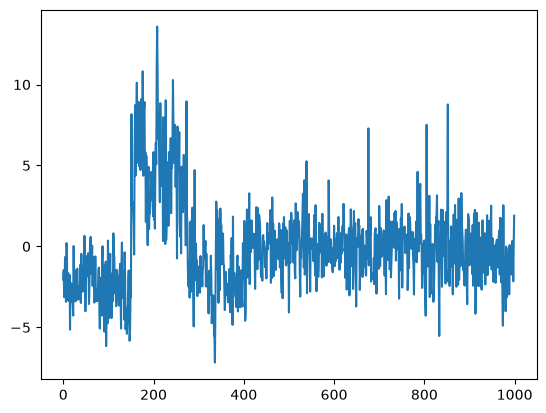

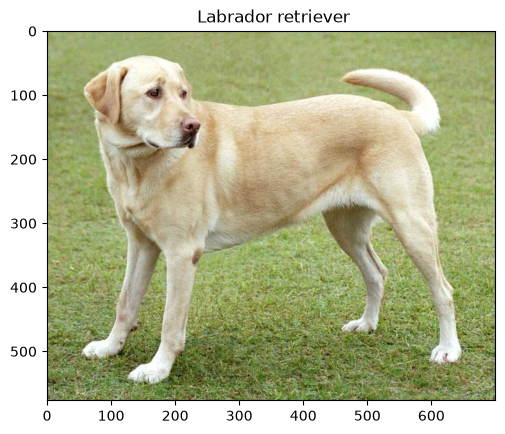

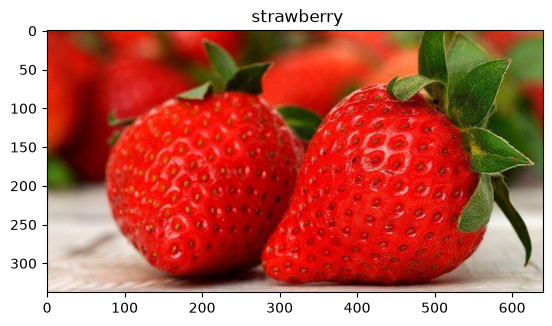

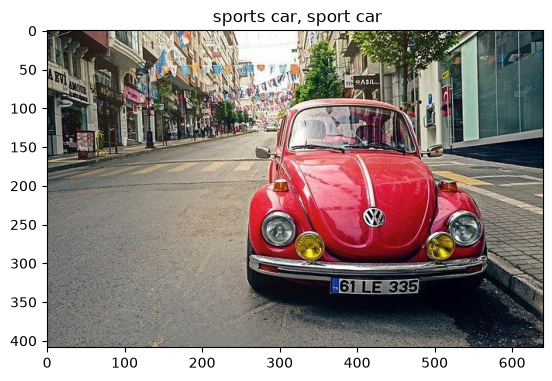

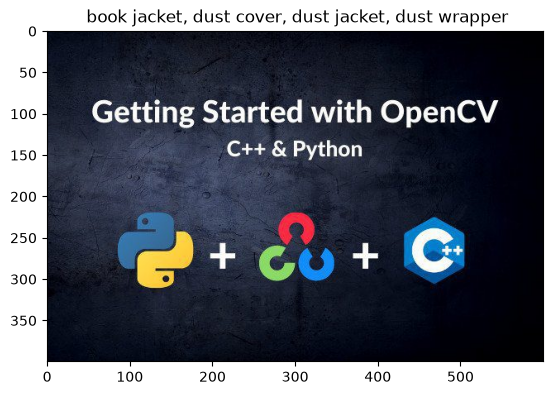

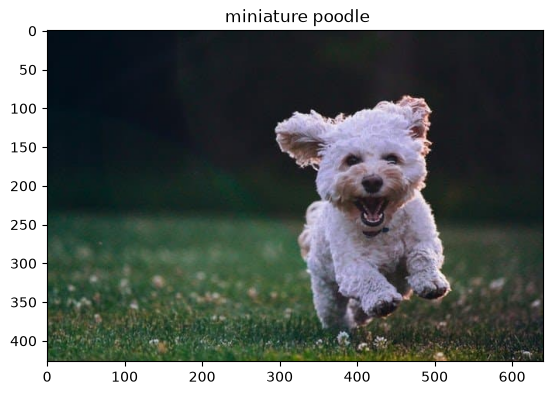

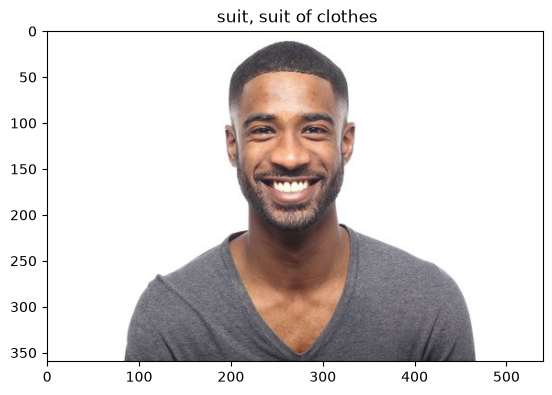

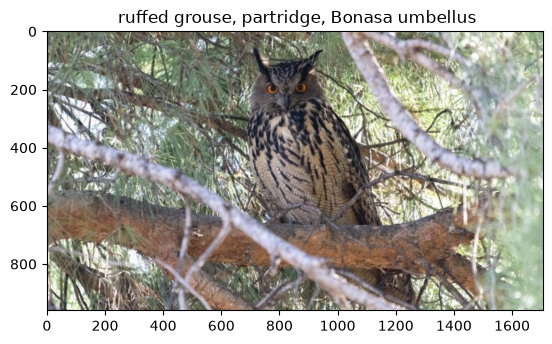

In [4]:
batch_t=torch.cat([torch.unsqueeze(transform(im),0) for im in imagenes], axis=0)
print(batch_t.shape)
resnet.eval()
out = resnet(batch_t)
print(out.shape)

plt.figure()
plt.plot(out.detach().numpy()[0])

_, index = torch.max(out, 1)
index=index.numpy()
i=0
for ind in index:
  plt.figure()
  plt.imshow(imagenes[i])
  plt.title(clases[ind])
  i+=1


torch.Size([64, 3, 7, 7])


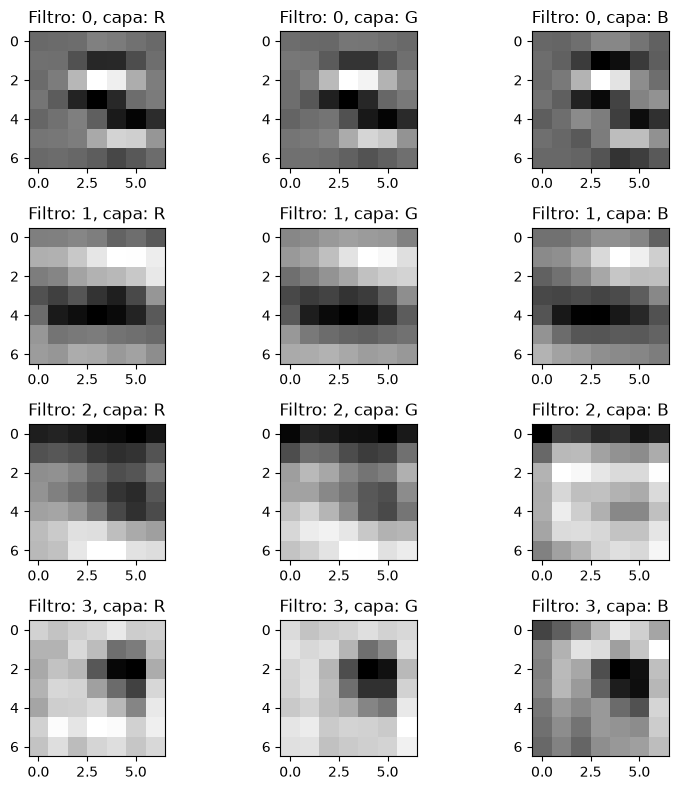

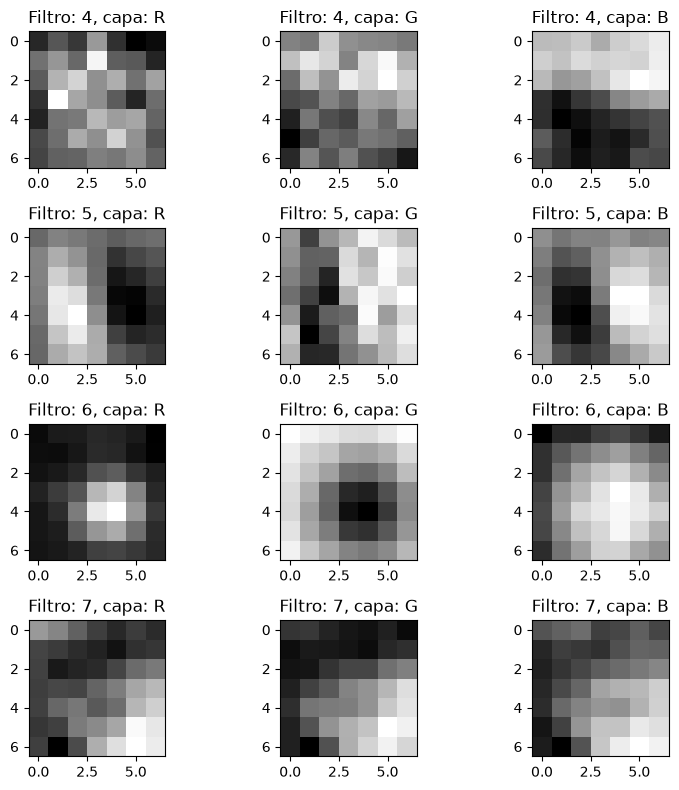

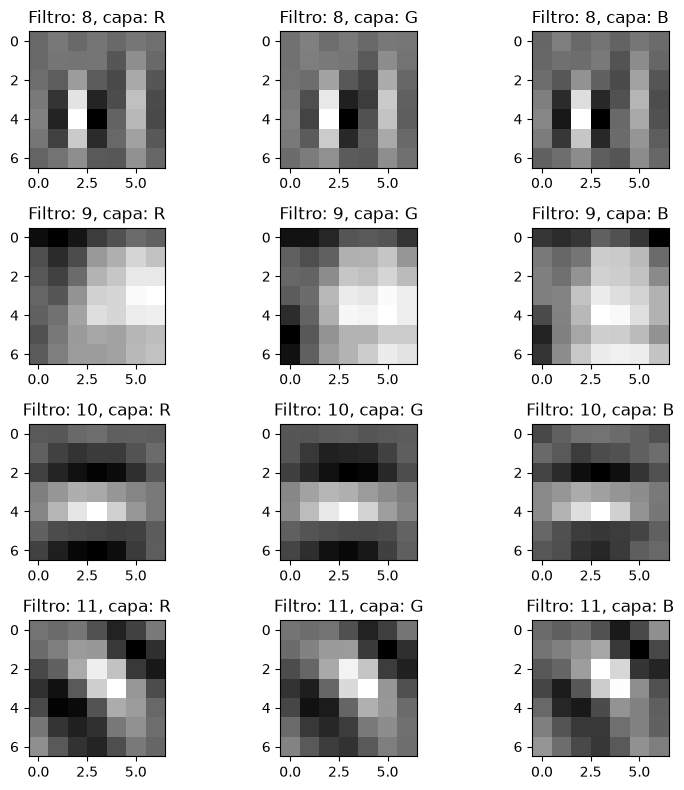

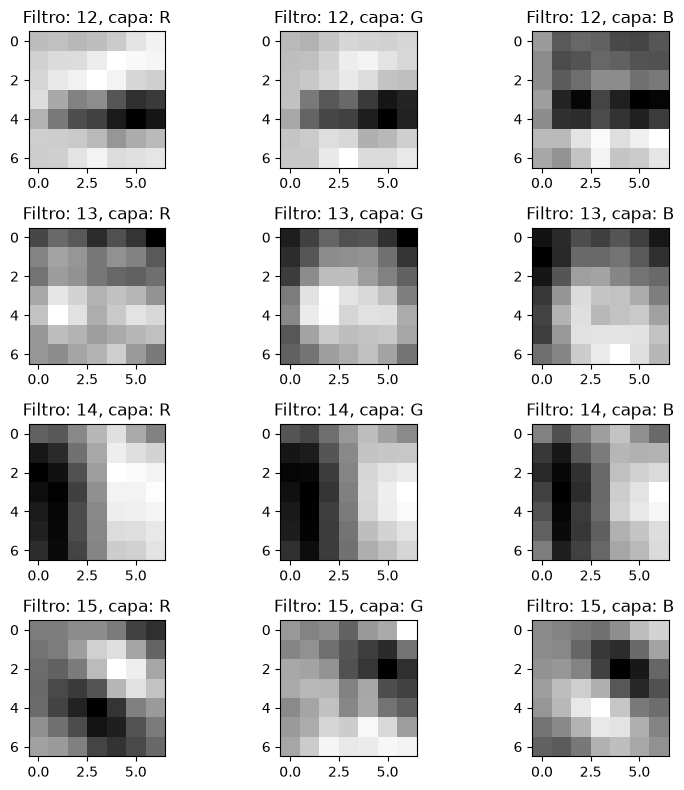

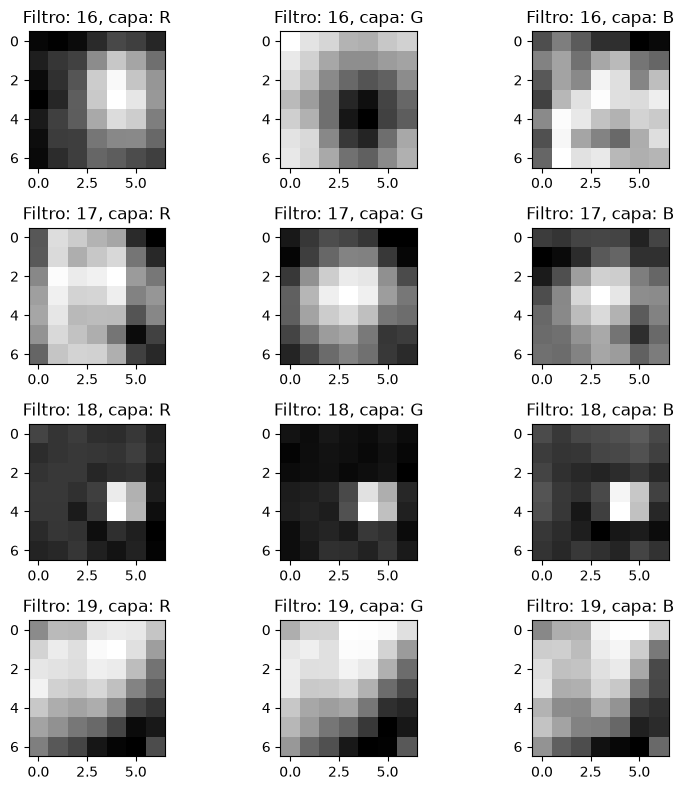

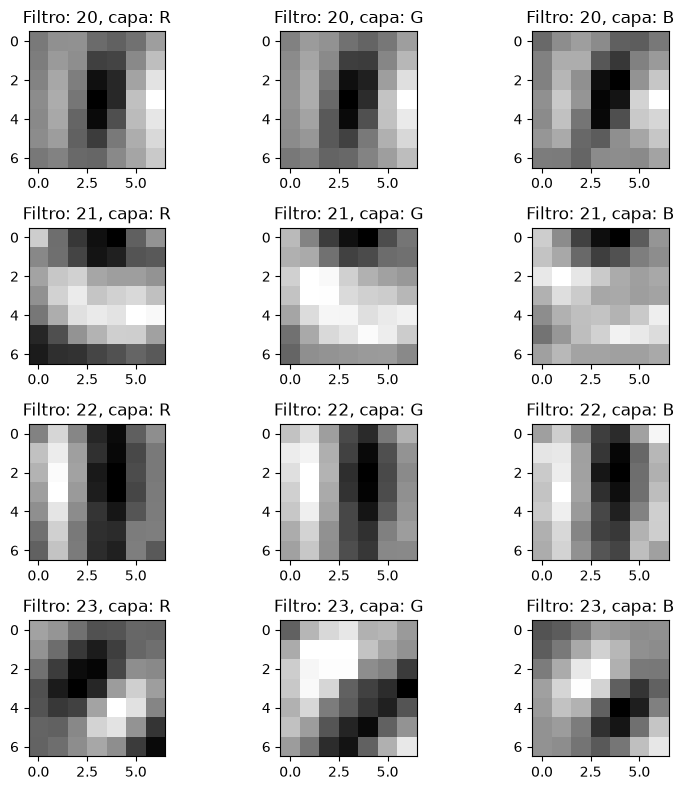

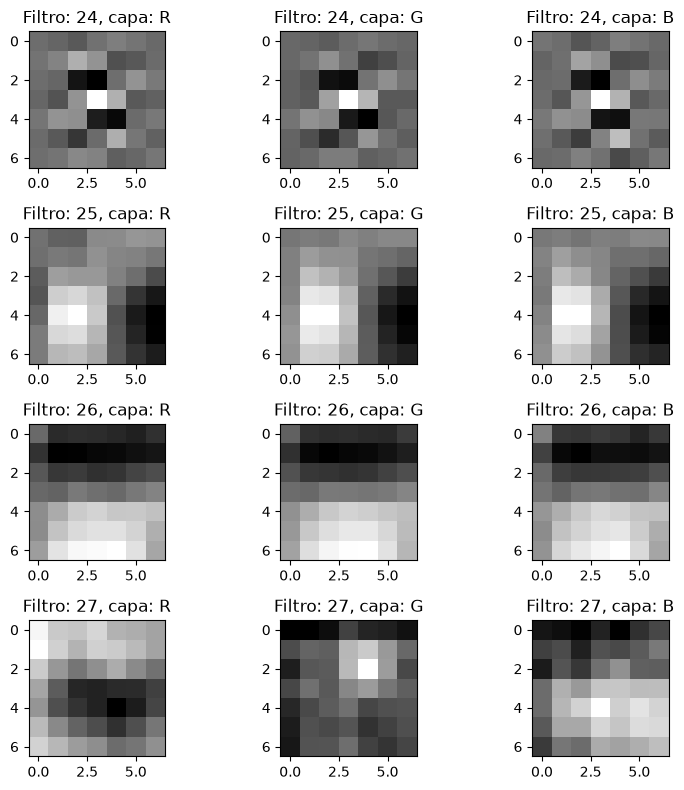

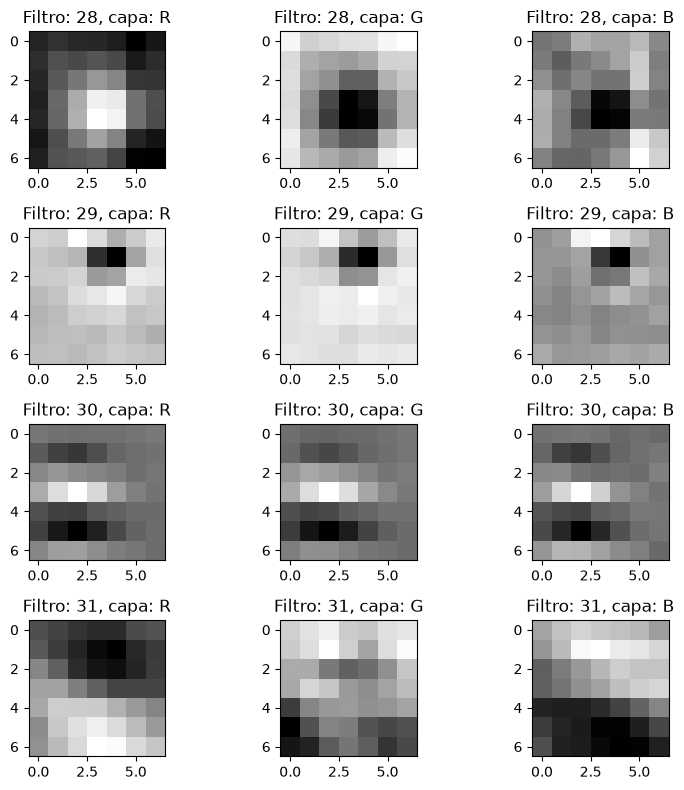

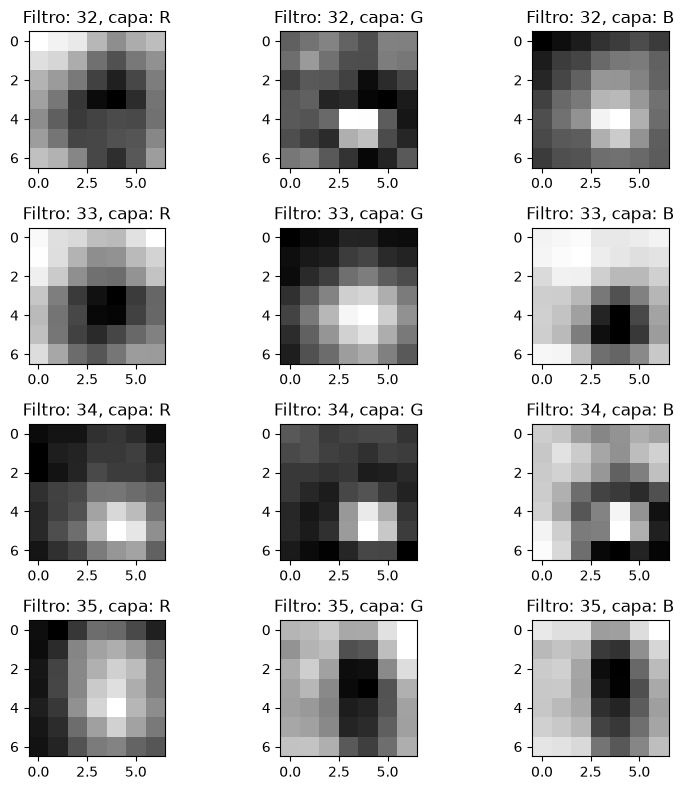

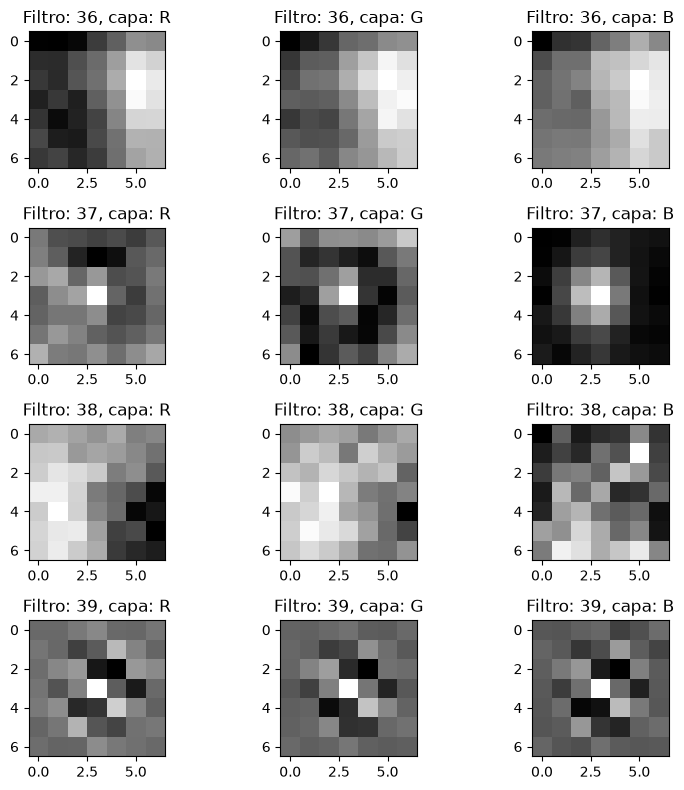

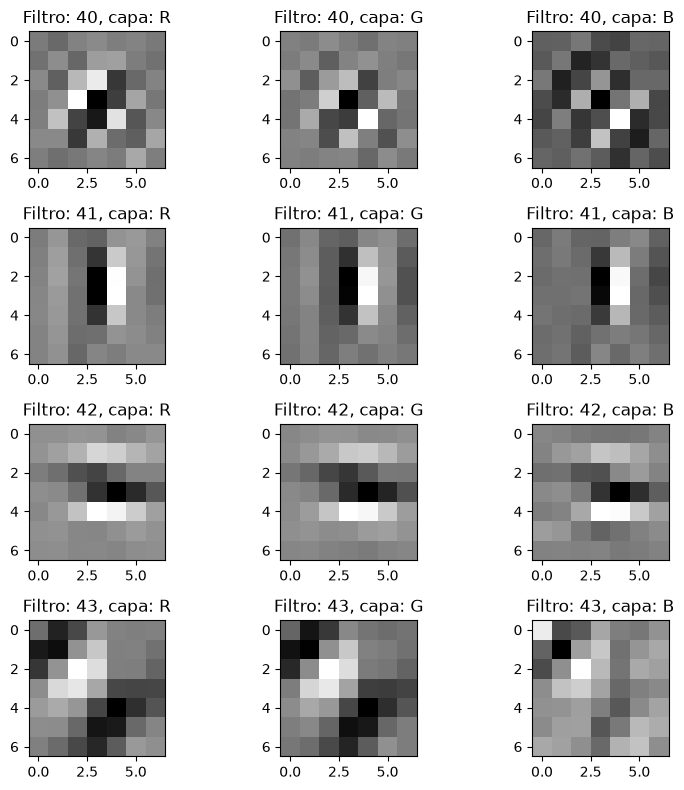

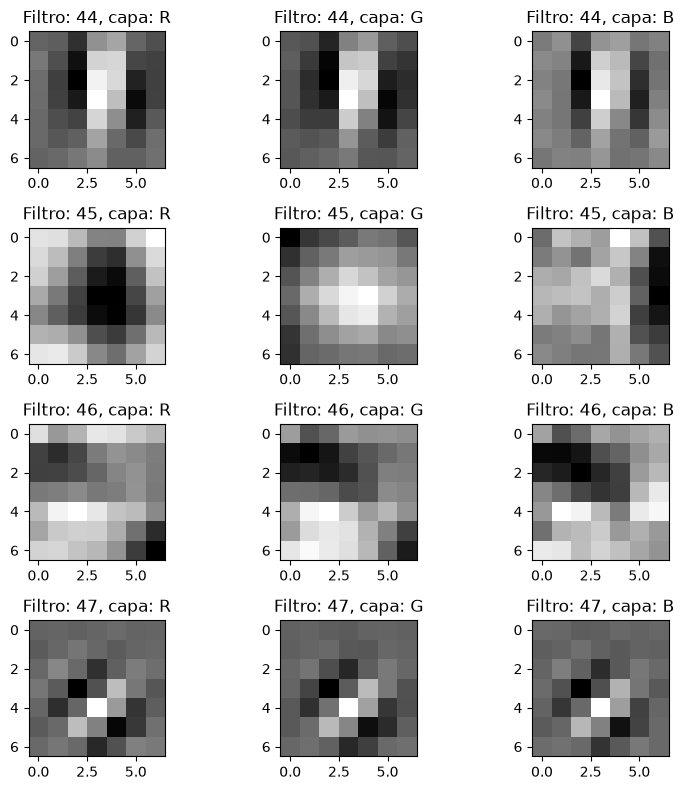

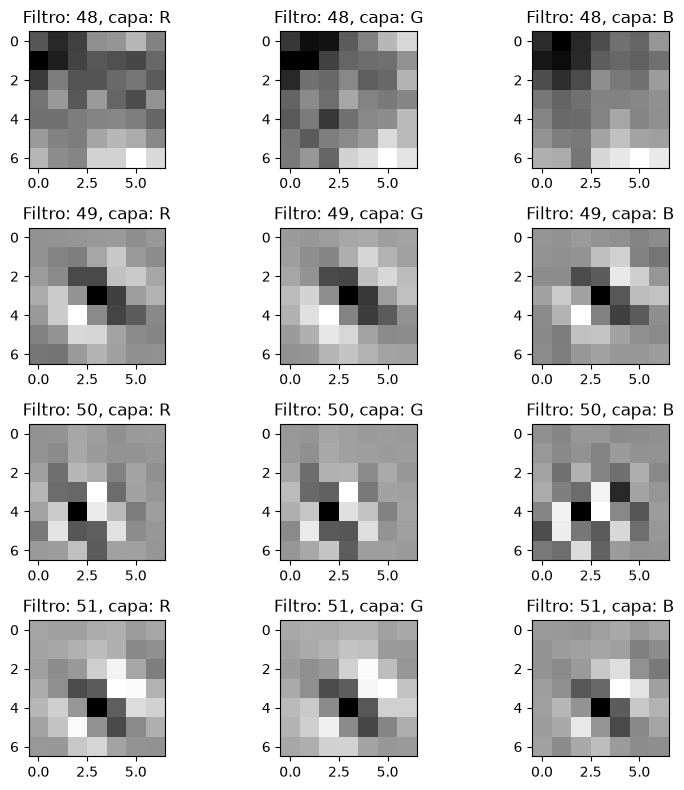

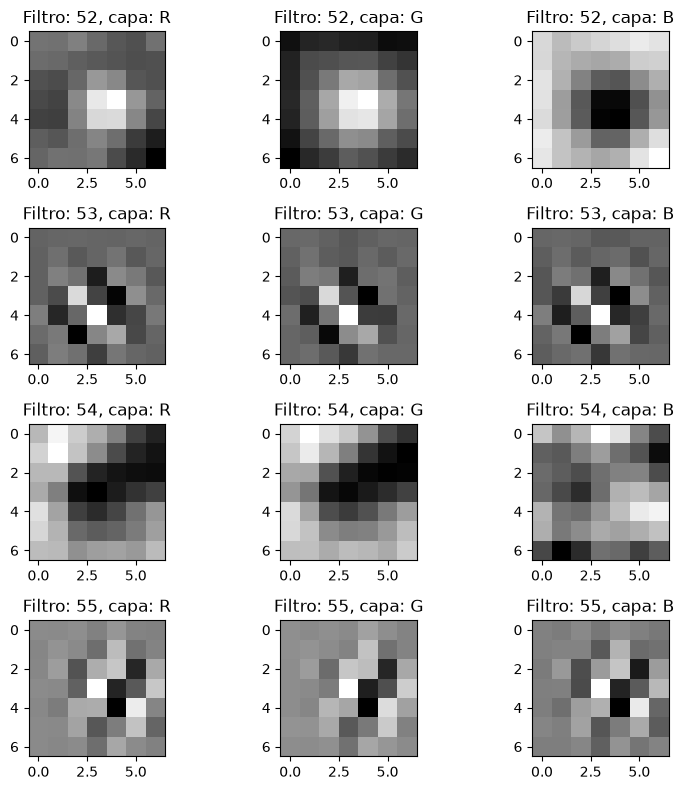

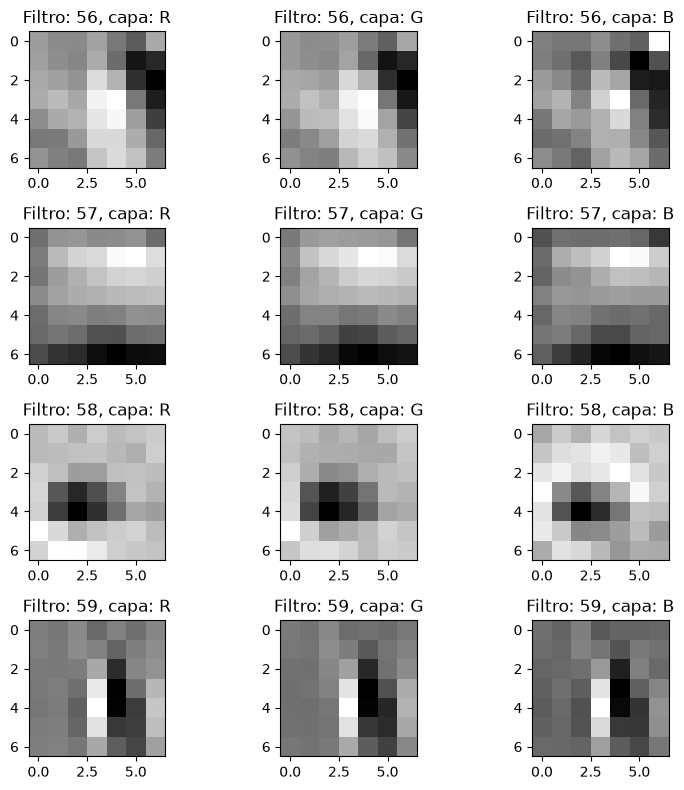

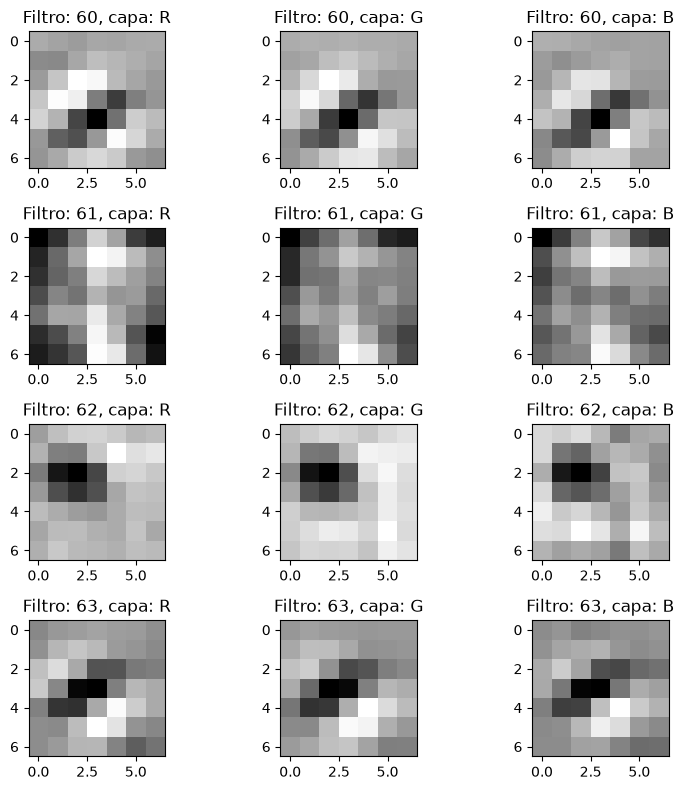

In [5]:
print(resnet.conv1.weight.shape)
capas=['R','G','B']
plt.figure(figsize=(8,8))

with(torch.no_grad()):
  ind=1
  for i in range(64):
    a=i#np.random.randint(64)
    for b in range(3):
      if(ind==13):
        plt.tight_layout()
        plt.figure(figsize=(8,8))
        ind=1
      x=resnet.conv1.weight[a,b,:,:].numpy()
      #print(x)
      plt.subplot(4,3,ind)
      ind+=1
      plt.imshow(x, cmap='gray')
      plt.title('Filtro: '+str(a)+', capa: '+capas[b])
plt.tight_layout()
